# Model Comparison
This notebook trains six classical machine learning algorithms on the preprocessed training set, performs cross-validation, evaluates them on the test set, and visualizes the results.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_all_years, get_train_test_split
from src.preprocessor import get_pipeline, fit_transform_train, transform_test, apply_smote
from src.models import train_all_models, cross_validate_all, MODELS
from src.evaluator import evaluate_model, compare_models
from src.visualizer import plot_roc_curves, plot_confusion_matrix

In [2]:
# Load and preprocess data
data_dir = os.path.join('..', 'data', 'raw')
df = load_all_years(data_dir)
X_train, X_test, y_train, y_test = get_train_test_split(df, test_size=0.2, random_state=42)

pipeline = get_pipeline()
X_train_scaled = fit_transform_train(pipeline, X_train)
X_test_scaled = transform_test(pipeline, X_test)
X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)

Raw ARFF files not found in data/raw/. Generating synthetic Polish bankruptcy dataset for demonstration.


In [3]:
# Run cross-validation
print("Running cross-validation on resampled training set...")
cv_results = cross_validate_all(MODELS, X_train_res, y_train_res, cv=5)
print("Cross Validation Results Summary:")
cv_results

Running cross-validation on resampled training set...


Cross Validation Results Summary:


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.1

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000e+00
1,Naive Bayes,0.998083,0.003834,1.000000,0.000000,0.996178,0.007643,0.998071,0.003859,1.000000,0.000000e+00
2,Decision Tree,0.993610,0.005346,0.989905,0.008542,0.997436,0.003140,0.993643,0.005322,0.993610,5.343712e-03
3,Random Forest,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,4.965068e-17
4,Gradient Boosting,0.997444,0.002391,0.994937,0.004736,1.000000,0.000000,0.997456,0.002382,0.999392,1.216724e-03
5,SVM,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000e+00


In [4]:
# Train all models
print("Training all models on training set...")
fitted_models = train_all_models(X_train_res, y_train_res)

# Evaluate on test set
results = {}
for name, model in fitted_models.items():
    results[name] = evaluate_model(model, X_test_scaled, y_test)
    print(f"\n=== {name} Test Set Classification Report ===")
    print(results[name]['classification_report'])

Training all models on training set...



=== Logistic Regression Test Set Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       196
           1       0.80      1.00      0.89         4

    accuracy                           0.99       200
   macro avg       0.90      1.00      0.94       200
weighted avg       1.00      0.99      1.00       200


=== Naive Bayes Test Set Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       196
           1       1.00      1.00      1.00         4

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


=== Decision Tree Test Set Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       196
           1       0.50      1.00      0.67         4

    accuracy    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [5]:
# Compare model metrics
df_compare = compare_models(results)
print("Model Test Set Comparison Table:")
df_compare

Model Test Set Comparison Table:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Naive Bayes,1.000,1.0,1.0,1.000000,1.000000
1,SVM,1.000,1.0,1.0,1.000000,1.000000
2,Logistic Regression,0.995,0.8,1.0,0.888889,1.000000
3,Random Forest,0.990,1.0,0.5,0.666667,1.000000
4,Gradient Boosting,0.980,0.5,1.0,0.666667,1.000000
5,Decision Tree,0.980,0.5,1.0,0.666667,0.989796


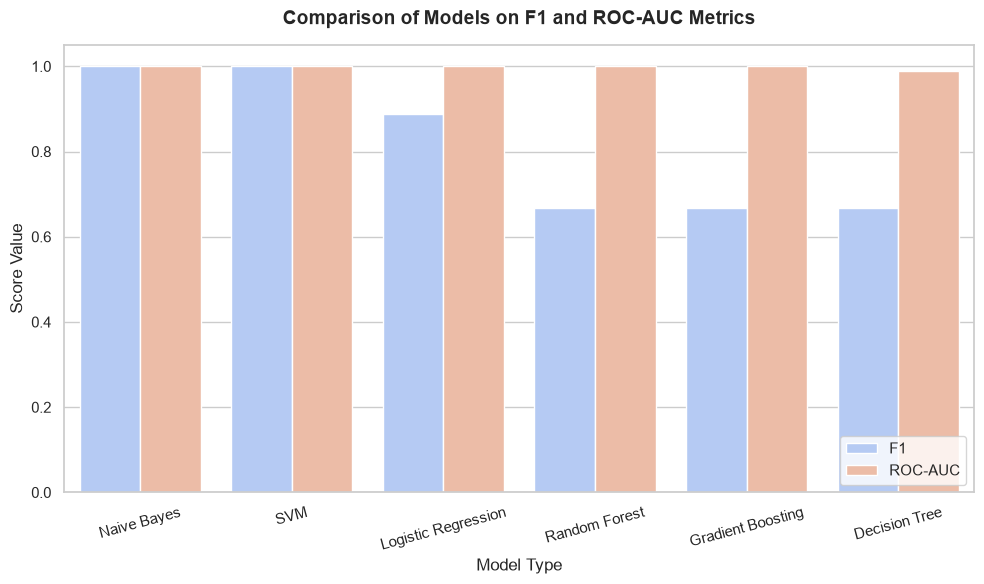

In [6]:
# Plot F1 and ROC-AUC metrics
melted_compare = df_compare.melt(id_vars=['Model'], value_vars=['F1', 'ROC-AUC'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_compare, palette='coolwarm')
plt.ylim([0, 1.05])
plt.xlabel('Model Type', fontsize=12)
plt.ylabel('Score Value', fontsize=12)
plt.title('Comparison of Models on F1 and ROC-AUC Metrics', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right')
plt.xticks(rotation=15)

save_path_bar = os.path.join('..', 'reports', 'figures', 'model_metric_comparison.png')
plt.tight_layout()
plt.savefig(save_path_bar, dpi=300)
plt.show()

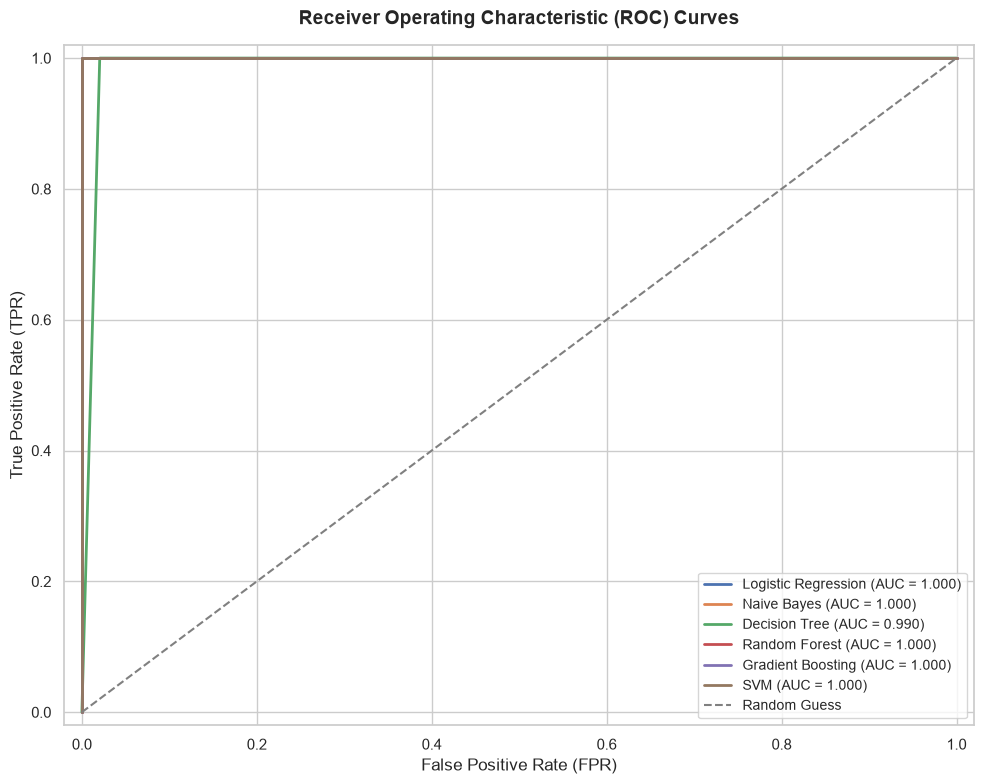

In [7]:
# Plot all ROC curves
save_path_roc = os.path.join('..', 'reports', 'figures', 'roc_curves.png')
plot_roc_curves(fitted_models, X_test_scaled, y_test, save_path=save_path_roc)

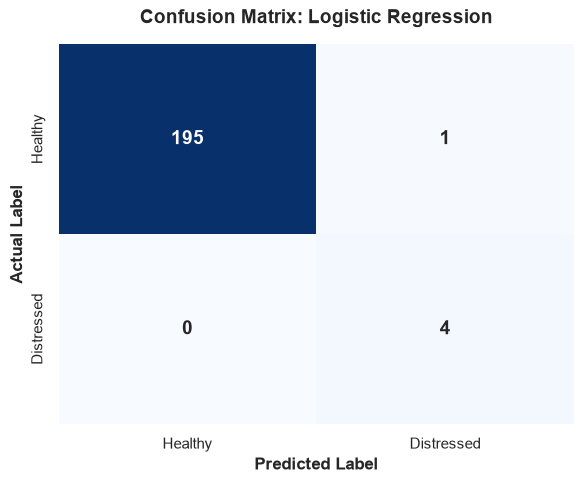

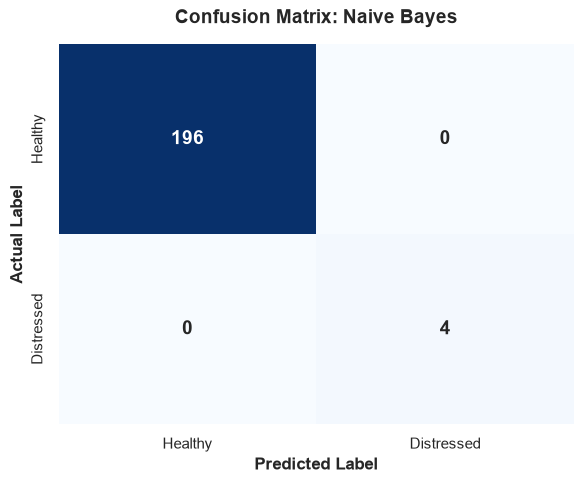

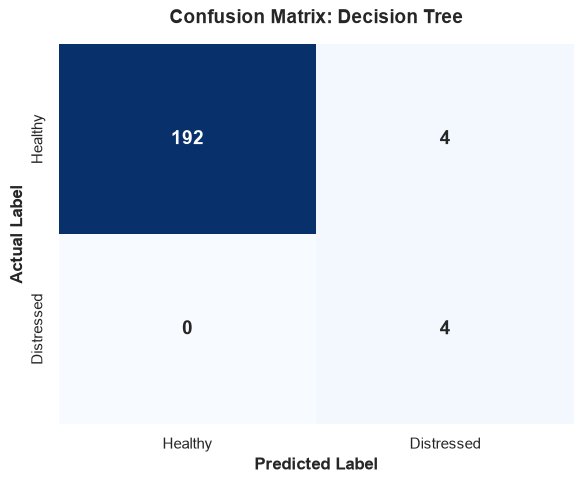

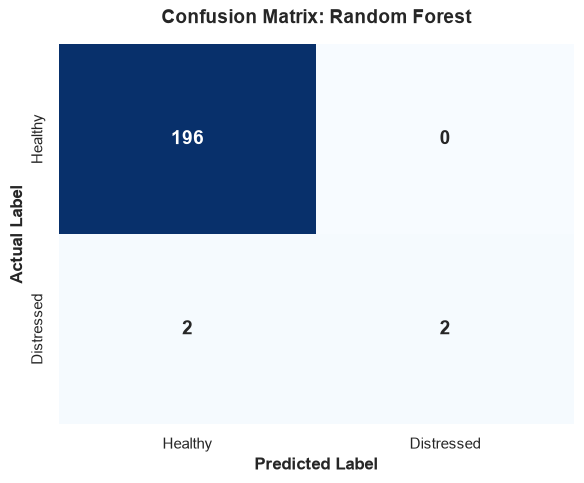

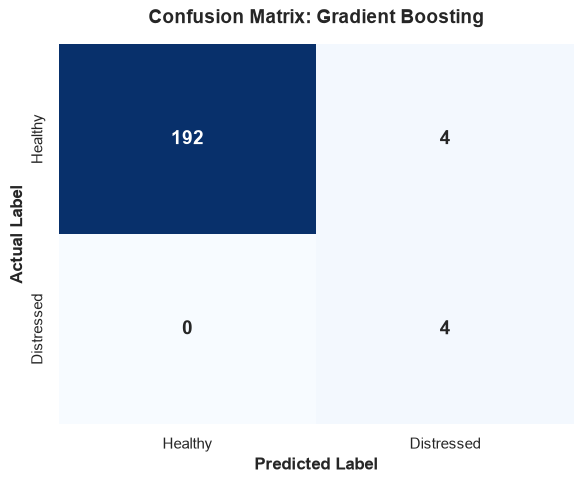

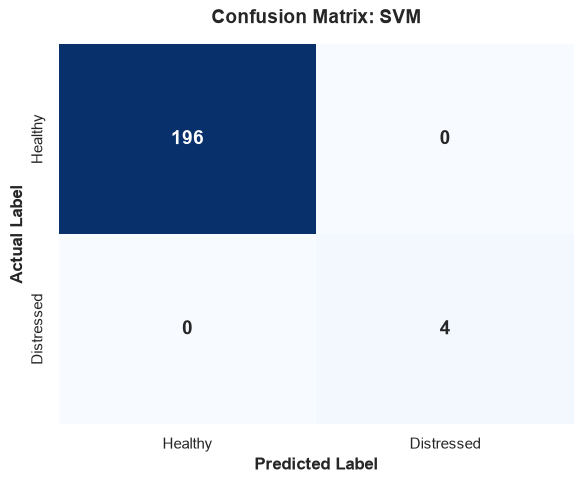

In [8]:
# Plot confusion matrices
for name, metrics in results.items():
    save_path_cm = os.path.join('..', 'reports', 'figures', f'confusion_matrix_{name.lower().replace(" ", "_")}.png')
    plot_confusion_matrix(metrics['confusion_matrix'], labels=['Healthy', 'Distressed'], title=f'Confusion Matrix: {name}', save_path=save_path_cm)